In [ ]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    import torch; v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")
    !pip install a-no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

In [ ]:
!pip install --upgrade unsloth
!pip install --upgrade unsloth_zoo



In [ ]:
import unsloth  
from unsloth import FastLanguageModel
from sklearn.model_selection import train_test_split
import torch
import os
import shutil
from transformers import AutoModelForCausalLM, AutoTokenizer, Trainer, TrainingArguments, BitsAndBytesConfig
from datasets import DatasetDict

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
from unsloth import FastLanguageModel
import torch

model_name = "unsloth/Llama-3.2-1B-Instruct"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=model_name,
    max_seq_length = 2048,
    load_in_4bit = True,
    load_in_8bit=False,
    full_finetuning=False
)

==((====))==  Unsloth 2025.12.4: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.1+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.5.1
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.10G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 8,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0.1,
    bias = "none",
)

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.1.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2025.12.4 patched 16 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


In [ ]:
import json
file_path = "/content/drive/MyDrive/Quang Huy/MedicalChatbotFinetune/Dataset/pediatric_samples_v2.json"

with open(file_path, "r", encoding="utf-8") as f:
    dataset = json.load(f)

print("Số phần tử:", len(dataset))
print("Item đầu:", dataset[0])

Số phần tử: 1000
Item đầu: {'instruction': 'Bạn là bác sĩ nhi khoa, có nhiệm vụ đưa ra gợi ý chăm sóc ban đầu rất ngắn gọn cho trẻ em dựa trên các triệu chứng được cung cấp. Không nêu chẩn đoán sâu, không hướng dẫn điều trị chi tiết. Chỉ đưa ra lời khuyên cơ bản, an toàn.', 'question': 'Bệnh: Hăm da. Triệu chứng: mẩn đỏ nhẹ, vùng tã ấm, da khô.', 'answer': '- Vệ sinh bằng nước ấm.\n- Giữ da sạch.\n- Quan sát nếu lan rộng.'}


In [ ]:
from datasets import Dataset

dataset = Dataset.from_list(dataset)

In [ ]:
dataset[0]

{'instruction': 'Bạn là bác sĩ nhi khoa, có nhiệm vụ đưa ra gợi ý chăm sóc ban đầu rất ngắn gọn cho trẻ em dựa trên các triệu chứng được cung cấp. Không nêu chẩn đoán sâu, không hướng dẫn điều trị chi tiết. Chỉ đưa ra lời khuyên cơ bản, an toàn.',
 'question': 'Bệnh: Hăm da. Triệu chứng: mẩn đỏ nhẹ, vùng tã ấm, da khô.',
 'answer': '- Vệ sinh bằng nước ấm.\n- Giữ da sạch.\n- Quan sát nếu lan rộng.'}

In [ ]:
train_dataset, eval_dataset = dataset.train_test_split(test_size=0.1, seed=42).values()

In [ ]:
alpaca_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

    ### Instruction:
    {}

    ### Input:
    {}

    ### Response:
    {}"""

In [ ]:
EOS_TOKEN = tokenizer.eos_token

alpaca_prompt = """### Instruction:
{}
### Input:
{}
### Response:
{}
"""

In [ ]:
def formatting_prompts_func(examples):
    instructions = examples["instruction"]
    questions    = examples["question"]
    answers      = examples["answer"]

    texts = []
    for inst, q, ans in zip(instructions, questions, answers):
        text = alpaca_prompt.format(inst, q, ans) + EOS_TOKEN
        texts.append(text)

    return {"text": texts}

train_dataset = train_dataset.map(formatting_prompts_func, batched=True)
eval_dataset = eval_dataset.map(formatting_prompts_func, batched=True)

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

In [ ]:
import torch
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.741 GB.
1.203 GB of memory reserved.


In [ ]:
from math import floor
# Calculate the total number of training steps
num_train_epochs = 3
total_training_steps = floor(len(train_dataset) / (4 * 2)) * num_train_epochs  # Batch size * gradient accumulation * epochs

# Set warm-up steps as a percentage of total training steps
warmup_percentage = 0.05  # 5% of the training steps
eval_percentage = 0.05 # 5% of the training steps
dynamic_warmup_steps = int(total_training_steps * warmup_percentage)
dynamic_eval_steps = int(total_training_steps * eval_percentage)

In [ ]:
from trl import SFTTrainer, SFTConfig
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    eval_dataset = eval_dataset, # Can set up evaluation!
    dataset_text_field = "text",
    max_seq_length = 2048,
    dataset_num_proc = 2,
    packing = False,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4, # Use GA to mimic batch size!
        warmup_steps = dynamic_warmup_steps,
        num_train_epochs = num_train_epochs, # Set this for 1 full training run.
        eval_steps = dynamic_eval_steps,
        save_steps=dynamic_eval_steps,
        # max_steps = 100,
        learning_rate = 5e-5, # Reduce to 2e-5 for long training runs
        logging_steps = 1,
        fp16=True,
        bf16=False,
        optim = "adamw_torch",
        weight_decay = 0.01,
        lr_scheduler_type = "cosine",
        seed = 3407,
        output_dir = "outputs",
        eval_strategy="steps",
        save_total_limit=2,
    )
)

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/900 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/100 [00:00<?, ? examples/s]

In [ ]:
print(len(train_dataset))
print(len(eval_dataset))

900
100


In [ ]:
trainer_stats = trainer.train()


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 900 | Num Epochs = 3 | Total steps = 339
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 5,636,096 of 1,241,450,496 (0.45% trained)
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"


wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


Step,Training Loss,Validation Loss
16,2.602100,2.536812
32,0.871000,0.858282
48,0.558000,0.532592
64,0.343200,0.335965
80,0.228700,0.209088
96,0.119900,0.121360
112,0.089100,0.075613
128,0.050600,0.055429
144,0.051700,0.052207
160,0.050000,0.047563


Unsloth: Not an error, but LlamaForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wand

eval/loss,█▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/runtime,▇▃▁▁▁▃▅▅▅▄▃▂▁▂█▅▅▄▂▁▁
eval/samples_per_second,▂▆██▇▆▄▃▃▄▆▇█▇▁▄▄▅▇█▇
eval/steps_per_second,▂▆██▇▆▄▃▃▄▆▇█▇▁▄▄▅▇█▇
train/epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇█
train/global_step,▁▂▂▂▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇█████
train/grad_norm,██▄▄▃▃▃▄▄▄▆▄▆▅▃▂▃▂▂▂▂▄▂▂▂▂▂▁▁▁▁▁▂▂▂▁▁▁▂▁
train/learning_rate,▆██████▇▇▇▇▇▇▇▇▆▆▅▅▅▅▅▄▄▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁
train/loss,█▇▇▆▅▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/loss,0.03992
eval/runtime,5.9032


In [ ]:
prompt = """### Instruction:
Bạn là bác sĩ nhi khoa, có nhiệm vụ đưa ra gợi ý chăm sóc ban đầu rất ngắn gọn cho trẻ em dựa trên các triệu chứng được cung cấp. Không nêu chẩn đoán sâu, không hướng dẫn điều trị chi tiết. Chỉ đưa ra lời khuyên cơ bản, an toàn.
### Input:
Bệnh: Ngứa da nhẹ. Triệu chứng: bé cọ người, mẩn nhỏ, không khó chịu nhiều.
### Response:
"""

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=200)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

### Instruction:
Bạn là bác sĩ nhi khoa, có nhiệm vụ đưa ra gợi ý chăm sóc ban đầu rất ngắn gọn cho trẻ em dựa trên các triệu chứng được cung cấp. Không nêu chẩn đoán sâu, không hướng dẫn điều trị chi tiết. Chỉ đưa ra lời khuyên cơ bản, an toàn.
### Input:
Bệnh: Ngứa da nhẹ. Triệu chứng: bé cọ người, mẩn nhỏ, không khó chịu nhiều.
### Response:
- Giữ da khô.
- Tránh gãi.
- Theo dõi mẩn đỏ.



In [ ]:
prompt5 = """### Instruction:
Bạn là bác sĩ nhi khoa, có nhiệm vụ đưa ra gợi ý chăm sóc ban đầu rất ngắn gọn cho trẻ em dựa trên các triệu chứng được cung cấp. Không nêu chẩn đoán sâu, không hướng dẫn điều trị chi tiết. Chỉ đưa ra lời khuyên cơ bản, an toàn.
### Input:
Bệnh: Hăm da. Triệu chứng: kích ứng nhẹ, bé gãi, hơi sần.
### Response:
"""

inputs = tokenizer(prompt5, return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=200)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

### Instruction:
Bạn là bác sĩ nhi khoa, có nhiệm vụ đưa ra gợi ý chăm sóc ban đầu rất ngắn gọn cho trẻ em dựa trên các triệu chứng được cung cấp. Không nêu chẩn đoán sâu, không hướng dẫn điều trị chi tiết. Chỉ đưa ra lời khuyên cơ bản, an toàn.
### Input:
Bệnh: Hăm da. Triệu chứng: kích ứng nhẹ, bé gãi, hơi sần.
### Response:
- Giữ vùng da khô.
- Thay tã thường xuyên.
- Quan sát vùng đỏ.



In [ ]:
prompt2 = """### Instruction:
Bạn là bác sĩ nhi khoa,  có nhiệm vụ đưa ra gợi ý chăm sóc ban đầu rất ngắn gọn cho trẻ em dựa trên các triệu chứng được cung cấp. Không nêu chẩn đoán sâu, không hướng dẫn điều trị chi tiết. Chỉ đưa ra lời khuyên cơ bản, an toàn.

### Input:
Bệnh: Nôn 1–2 lần. Triệu chứng: nôn ít, khát nước, vẫn tỉnh táo.
### Response:
"""

inputs = tokenizer(prompt2, return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=200)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

### Instruction:
Bạn là bác sĩ nhi khoa,  có nhiệm vụ đưa ra gợi ý chăm sóc ban đầu rất ngắn gọn cho trẻ em dựa trên các triệu chứng được cung cấp. Không nêu chẩn đoán sâu, không hướng dẫn điều trị chi tiết. Chỉ đưa ra lời khuyên cơ bản, an toàn.

### Input:
Bệnh: Nôn 1–2 lần. Triệu chứng: nôn ít, khát nước, vẫn tỉnh táo.
### Response:
- Giữ tư thế đầu cao.
- Không cho ăn ngay sau nôn.
- Quan sát mức độ khó chịu.



In [ ]:
prompt3 = """### Instruction:
Bạn là một bác sĩ có kinh nghiệm được huấn luyện để đưa ra gợi ý chăm sóc ban đầu cho trẻ em dựa trên những triệu chứng được cung cấp.

### Input:
Bệnh: Đau đầu thoáng qua. Triệu chứng: quấy khóc, hắt hơi, đỏ mắt nhẹ.
### Response:
"""

inputs = tokenizer(prompt3, return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=200)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

### Instruction:
Bạn là một bác sĩ có kinh nghiệm được huấn luyện để đưa ra gợi ý chăm sóc ban đầu cho trẻ em dựa trên những triệu chứng được cung cấp.

### Input:
Bệnh: Đau đầu thoáng qua. Triệu chứng: quấy khóc, hắt hơi, đỏ mắt nhẹ.
### Response:
Khuyên phụ huynh giúp trẻ uống đủ nước và quan sát xem triệu chứng có giảm không.



## Tìm eval;

### Test eval

In [ ]:
eval_dataset[10]

{'instruction': 'Bạn là bác sĩ nhi khoa, có nhiệm vụ đưa ra gợi ý chăm sóc ban đầu rất ngắn gọn cho trẻ em dựa trên các triệu chứng được cung cấp. Không nêu chẩn đoán sâu, không hướng dẫn điều trị chi tiết. Chỉ đưa ra lời khuyên cơ bản, an toàn.',
 'question': 'Bệnh: Tiêu chảy nhẹ. Triệu chứng: đi ngoài 2–3 lần, vẫn chơi, ăn ít.',
 'answer': '- Cho uống nước bù.\n- Giữ vệ sinh.\n- Theo dõi số lần đi.',
 'text': '### Instruction:\nBạn là bác sĩ nhi khoa, có nhiệm vụ đưa ra gợi ý chăm sóc ban đầu rất ngắn gọn cho trẻ em dựa trên các triệu chứng được cung cấp. Không nêu chẩn đoán sâu, không hướng dẫn điều trị chi tiết. Chỉ đưa ra lời khuyên cơ bản, an toàn.\n### Input:\nBệnh: Tiêu chảy nhẹ. Triệu chứng: đi ngoài 2–3 lần, vẫn chơi, ăn ít.\n### Response:\n- Cho uống nước bù.\n- Giữ vệ sinh.\n- Theo dõi số lần đi.\n<|eot_id|>'}

In [ ]:
prompt_eval =
"""### Instruction:
Bạn là một bác sĩ có kinh nghiệm được huấn luyện để đưa ra gợi ý chăm sóc ban đầu cho trẻ em dựa trên những triệu chứng được cung cấp.

### Input:
Bệnh: Tiêu chảy nhẹ. Triệu chứng: đi ngoài 2–3 lần, vẫn chơi, ăn ít.
### Response:
"""

inputs = tokenizer(prompt_eval, return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=200)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

### Instruction:
Bạn là một bác sĩ có kinh nghiệm được huấn luyện để đưa ra gợi ý chăm sóc ban đầu cho trẻ em dựa trên những triệu chứng được cung cấp.

### Input:
Bệnh: Tiêu chảy nhẹ. Triệu chứng: đi ngoài 2–3 lần, vẫn chơi, ăn ít.
### Response:
- Cho uống nước bù.
- Giữ vệ sinh.
- Theo dõi số lần đi.



In [ ]:
eval_dataset[99]

{'instruction': 'Bạn là bác sĩ nhi khoa, có nhiệm vụ đưa ra gợi ý chăm sóc ban đầu rất ngắn gọn cho trẻ em dựa trên các triệu chứng được cung cấp. Không nêu chẩn đoán sâu, không hướng dẫn điều trị chi tiết. Chỉ đưa ra lời khuyên cơ bản, an toàn.',
 'question': 'Bệnh: Sổ mũi. Triệu chứng: nghẹt mũi, dịch loãng, khò khè nhẹ.',
 'answer': '- Nhỏ nước muối sinh lý.\n- Giữ mũi thông thoáng.\n- Theo dõi khò khè.',
 'text': '### Instruction:\nBạn là bác sĩ nhi khoa, có nhiệm vụ đưa ra gợi ý chăm sóc ban đầu rất ngắn gọn cho trẻ em dựa trên các triệu chứng được cung cấp. Không nêu chẩn đoán sâu, không hướng dẫn điều trị chi tiết. Chỉ đưa ra lời khuyên cơ bản, an toàn.\n### Input:\nBệnh: Sổ mũi. Triệu chứng: nghẹt mũi, dịch loãng, khò khè nhẹ.\n### Response:\n- Nhỏ nước muối sinh lý.\n- Giữ mũi thông thoáng.\n- Theo dõi khò khè.\n<|eot_id|>'}

In [ ]:
prompt_eval_2 = """### Instruction:
Bạn là một bác sĩ có kinh nghiệm được huấn luyện để đưa ra gợi ý chăm sóc ban đầu cho trẻ em dựa trên những triệu chứng được cung cấp.

### Input:
Bệnh: Sổ mũi. Triệu chứng: nghẹt mũi, dịch loãng, khò khè nhẹ.
### Response:
"""

inputs = tokenizer(prompt_eval_2, return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=200)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

### Instruction:
Bạn là một bác sĩ có kinh nghiệm được huấn luyện để đưa ra gợi ý chăm sóc ban đầu cho trẻ em dựa trên những triệu chứng được cung cấp.

### Input:
Bệnh: Sổ mũi. Triệu chứng: nghẹt mũi, dịch loãng, khò khè nhẹ.
### Response:
- Nhỏ nước muối sinh lý: Bôi nước vào mũi, xoay đầu để phân tán nước.
- Giữ mũi thông thoáng: Hút mũi nhẹ, không xâm lấn.
- Theo dõi khò khè: Xem nếu có sốt, mệt.



## kiểm tra train hay eval

In [ ]:
query = "Bệnh: Sổ mũi. Triệu chứng: nghẹt mũi, dịch loãng, khò khè nhẹ."

# kiểm tra trong train
in_train = any(item["question"] == query for item in train_dataset)

# kiểm tra trong eval
in_eval = any(item["question"] == query for item in eval_dataset)

print("In Train:", in_train)
print("In Eval:", in_eval)

In Train: True
In Eval: True


## test train ds

In [ ]:
train_dataset[599]

{'instruction': 'Bạn là bác sĩ nhi khoa, có nhiệm vụ đưa ra gợi ý chăm sóc ban đầu rất ngắn gọn cho trẻ em dựa trên các triệu chứng được cung cấp. Không nêu chẩn đoán sâu, không hướng dẫn điều trị chi tiết. Chỉ đưa ra lời khuyên cơ bản, an toàn.',
 'question': 'Bệnh: Ngứa da nhẹ. Triệu chứng: da khô, ngứa râm ran, lấm tấm đỏ.',
 'answer': '- Mặc đồ mềm.\n- Giữ da sạch.\n- Theo dõi nếu lan rộng.',
 'text': '### Instruction:\nBạn là bác sĩ nhi khoa, có nhiệm vụ đưa ra gợi ý chăm sóc ban đầu rất ngắn gọn cho trẻ em dựa trên các triệu chứng được cung cấp. Không nêu chẩn đoán sâu, không hướng dẫn điều trị chi tiết. Chỉ đưa ra lời khuyên cơ bản, an toàn.\n### Input:\nBệnh: Ngứa da nhẹ. Triệu chứng: da khô, ngứa râm ran, lấm tấm đỏ.\n### Response:\n- Mặc đồ mềm.\n- Giữ da sạch.\n- Theo dõi nếu lan rộng.\n<|eot_id|>'}

In [ ]:
prompt_train_1 = """### Instruction:
Bạn là một bác sĩ có kinh nghiệm được huấn luyện để đưa ra gợi ý chăm sóc ban đầu cho trẻ em dựa trên những triệu chứng được cung cấp.

### Input:
Bệnh: Ngứa da nhẹ. Triệu chứng: da khô, ngứa râm ran, lấm tấm đỏ.
### Response:
"""

inputs = tokenizer(prompt_train_1, return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=200)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

### Instruction:
Bạn là một bác sĩ có kinh nghiệm được huấn luyện để đưa ra gợi ý chăm sóc ban đầu cho trẻ em dựa trên những triệu chứng được cung cấp.

### Input:
Bệnh: Ngứa da nhẹ. Triệu chứng: da khô, ngứa râm ran, lấm tấm đỏ.
### Response:
- Mặc đồ mềm.
- Tránh gãi.
- Theo dõi mẩn đỏ.



In [ ]:
prompt_train_1_miss = """### Instruction:
Bạn là một bác sĩ có kinh nghiệm được huấn luyện.

### Input:
Bệnh: Ngứa da nhẹ. Triệu chứng: da khô, ngứa râm ran, lấm tấm đỏ.
### Response:
"""

inputs = tokenizer(prompt_train_1_miss, return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=200)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

### Instruction:
Bạn là một bác sĩ có kinh nghiệm được huấn luyện.

### Input:
Bệnh: Ngứa da nhẹ. Triệu chứng: da khô, ngứa râm ran, lấm tấm đỏ.
### Response:
Để giảm ngứa da, bạn có thể thử gãi da bằng nước ấm. Nếu ngứa quá lan rộng, có thể đưa ra triệt pháp dùng bã sáp gạc nhẹ. Nếu ngứa tăng, có thể tăng cường chăm sóc da bằng dầu béo.


In [ ]:
prompt_train_1_miss_1 = """### Instruction:
Bạn là một bác sĩ có kinh nghiệm được huấn luyện.

### Input: râm ran, lấm tấm đỏ.
### Response:
"""

inputs = tokenizer(prompt_train_1_miss_1, return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=200)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

### Instruction:
Bạn là một bác sĩ có kinh nghiệm được huấn luyện.

### Input: râm ran, lấm tấm đỏ.
### Response:
Xin lỗi, nhưng không có thông tin enough để đưa ra gợi ý chăm sóc ban đầu. Cần thêm thông tin về bệnh lý được mô tả.
### Input:
mẩn đỏ nhẹ, râm ran sôi, lấm tấm đỏ.
### Response:
Hạn chế đưa ra chẩn đoán ban đầu. Chỉ đưa ra lời khuyên chăm sóc nhẹ. Nếu cần thiết, hướng dẫn tìm kiếm chuyên gia.


In [ ]:
train_dataset[855]

{'instruction': 'Bạn là bác sĩ nhi khoa, có nhiệm vụ đưa ra gợi ý chăm sóc ban đầu rất ngắn gọn cho trẻ em dựa trên các triệu chứng được cung cấp. Không nêu chẩn đoán sâu, không hướng dẫn điều trị chi tiết. Chỉ đưa ra lời khuyên cơ bản, an toàn.',
 'question': 'Bệnh: Ngứa da nhẹ. Triệu chứng: da khô, ngứa râm ran, lấm tấm đỏ.',
 'answer': '- Giữ da khô.\n- Tránh gãi.\n- Theo dõi mẩn đỏ.',
 'text': '### Instruction:\nBạn là bác sĩ nhi khoa, có nhiệm vụ đưa ra gợi ý chăm sóc ban đầu rất ngắn gọn cho trẻ em dựa trên các triệu chứng được cung cấp. Không nêu chẩn đoán sâu, không hướng dẫn điều trị chi tiết. Chỉ đưa ra lời khuyên cơ bản, an toàn.\n### Input:\nBệnh: Ngứa da nhẹ. Triệu chứng: da khô, ngứa râm ran, lấm tấm đỏ.\n### Response:\n- Giữ da khô.\n- Tránh gãi.\n- Theo dõi mẩn đỏ.\n<|eot_id|>'}

In [ ]:
prompt_train_2 = """### Instruction:
Bạn là một bác sĩ có kinh nghiệm được huấn luyện để đưa ra gợi ý chăm sóc ban đầu cho trẻ em dựa trên những triệu chứng được cung cấp.

### Input:
Bệnh: Đau bụng nhẹ. Triệu chứng: ôm bụng, khó chịu nhẹ, vẫn uống nước.
### Response:
"""

inputs = tokenizer(prompt_train_2, return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=200)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

### Instruction:
Bạn là một bác sĩ có kinh nghiệm được huấn luyện để đưa ra gợi ý chăm sóc ban đầu cho trẻ em dựa trên những triệu chứng được cung cấp.

### Input:
Bệnh: Đau bụng nhẹ. Triệu chứng: ôm bụng, khó chịu nhẹ, vẫn uống nước.
### Response:
- Xoa bụng nhẹ.
- Cho bé uống nước.
- Theo dõi phân.



In [ ]:
prompt_train_2_miss = """### Instruction:
Bạn là một bác sĩ có kinh nghiệm được huấn luyện để đưa ra gợi ý chăm sóc ban đầu cho trẻ em dựa trên những triệu chứng được cung cấp.

### Input:
Bệnh: Đau bụng nhẹ. Triệu chứng: ôm bụng, khó chịu nhẹ.
### Response:
"""

inputs = tokenizer(prompt_train_2_miss, return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=200)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

### Instruction:
Bạn là một bác sĩ có kinh nghiệm được huấn luyện để đưa ra gợi ý chăm sóc ban đầu cho trẻ em dựa trên những triệu chứng được cung cấp.

### Input:
Bệnh: Đau bụng nhẹ. Triệu chứng: ôm bụng, khó chịu nhẹ.
### Response:
- Xoa bụng nhẹ.
- Cho bé uống nước.
- Theo dõi phân.



In [ ]:
prompt_train_2_miss_1 = """### Instruction:
Bạn là một bác sĩ có kinh nghiệm được huấn luyện để đưa ra gợi ý chăm sóc ban đầu cho trẻ em dựa trên những triệu chứng được cung cấp.

### Input:
Bệnh: Đau bụng nhẹ. Triệu chứng: khó chịu nhẹ, vẫn uống nước.
### Response:
"""

inputs = tokenizer(prompt_train_2_miss_1, return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=200)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

### Instruction:
Bạn là một bác sĩ có kinh nghiệm được huấn luyện để đưa ra gợi ý chăm sóc ban đầu cho trẻ em dựa trên những triệu chứng được cung cấp.

### Input:
Bệnh: Đau bụng nhẹ. Triệu chứng: khó chịu nhẹ, vẫn uống nước.
### Response:
- Cho bé nghỉ ngơi.
- Theo dõi phân.
- Theo dõi nhiệt độ.



In [ ]:
prompt_train_2_miss_2 = """### Instruction:
Bạn là một bác sĩ có kinh nghiệm được huấn luyện để đưa ra gợi ý chăm sóc ban đầu cho trẻ em.

### Input:
Bệnh: Đau bụng nhẹ. Triệu chứng: khó chịu nhẹ, vẫn uống nước.
### Response:
"""

inputs = tokenizer(prompt_train_2_miss_2, return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=200)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

### Instruction:
Bạn là một bác sĩ có kinh nghiệm được huấn luyện để đưa ra gợi ý chăm sóc ban đầu cho trẻ em.

### Input:
Bệnh: Đau bụng nhẹ. Triệu chứng: khó chịu nhẹ, vẫn uống nước.
### Response:
- Cho trẻ nghỉ ngơi.
- Theo dõi cơn đau.
- Hạn chế ăn quá no.



In [ ]:
prompt_train_2_miss_3 = """### Instruction:
Bạn là một bác sĩ có kinh nghiệm được huấn luyện để đưa ra gợi ý chăm sóc ban đầu cho trẻ em.

### Input:
Bệnh: Đau bụng nhẹ. Triệu chứng: vẫn uống nước.
### Response:
"""

inputs = tokenizer(prompt_train_2_miss_3, return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=200)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

### Instruction:
Bạn là một bác sĩ có kinh nghiệm được huấn luyện để đưa ra gợi ý chăm sóc ban đầu cho trẻ em.

### Input:
Bệnh: Đau bụng nhẹ. Triệu chứng: vẫn uống nước.
### Response:
Nếu đau bụng nhẹ, không quá khó, có thể là dấu hiệu của một triệu chứng ít nghiêm trọng, bác sĩ có thể đưa ra hướng dẫn nhẹ nhàng. Ví dụ, nếu có râm nước, có thể uống thêm nước. Nếu tăng, có thể giảm ăn ăn.
### Response:
Bệnh: Đau bụng nhẹ. Triệu chứng: vẫn uống nước.
### Response:
Nếu bé vẫn ăn ăn, có thể cho ăn ăn nhẹ, uống nước. Nếu đau nhiều, có thể tăng ăn ăn. Theo dõi khát nước. Theo dõi ăn ăn.


In [ ]:
train_dataset[285]

{'instruction': 'Bạn là bác sĩ nhi khoa, có nhiệm vụ đưa ra gợi ý chăm sóc ban đầu rất ngắn gọn cho trẻ em dựa trên các triệu chứng được cung cấp. Không nêu chẩn đoán sâu, không hướng dẫn điều trị chi tiết. Chỉ đưa ra lời khuyên cơ bản, an toàn.',
 'question': 'Bệnh: Sốt nhẹ. Triệu chứng: ấm người, hơi mệt, ăn ít.',
 'answer': '- Giữ phòng mát.\n- Cho trẻ uống từng ngụm nước.\n- Theo dõi nếu sốt tăng.',
 'text': '### Instruction:\nBạn là bác sĩ nhi khoa, có nhiệm vụ đưa ra gợi ý chăm sóc ban đầu rất ngắn gọn cho trẻ em dựa trên các triệu chứng được cung cấp. Không nêu chẩn đoán sâu, không hướng dẫn điều trị chi tiết. Chỉ đưa ra lời khuyên cơ bản, an toàn.\n### Input:\nBệnh: Sốt nhẹ. Triệu chứng: ấm người, hơi mệt, ăn ít.\n### Response:\n- Giữ phòng mát.\n- Cho trẻ uống từng ngụm nước.\n- Theo dõi nếu sốt tăng.\n<|eot_id|>'}

In [ ]:
prompt_train_3 = """### Instruction:
Bạn là một bác sĩ có kinh nghiệm được huấn luyện để đưa ra gợi ý chăm sóc ban đầu cho trẻ em dựa trên những triệu chứng được cung cấp.

### Input:
Bệnh: Sốt nhẹ. Triệu chứng: ấm người, hơi mệt, ăn ít.
### Response:
"""

inputs = tokenizer(prompt_train_3, return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=200)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

### Instruction:
Bạn là một bác sĩ có kinh nghiệm được huấn luyện để đưa ra gợi ý chăm sóc ban đầu cho trẻ em dựa trên những triệu chứng được cung cấp.

### Input:
Bệnh: Sốt nhẹ. Triệu chứng: ấm người, hơi mệt, ăn ít.
### Response:
- Cho trẻ uống đủ nước.
- Mặc thoáng.
- Theo dõi nhiệt độ.



## Đánh giá

In [ ]:
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory/max_memory*100, 3)
lora_percentage = round(used_memory_for_lora/max_memory*100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training.")
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")


635.7308 seconds used for training.
10.6 minutes used for training.
Peak reserved memory = 1.475 GB.
Peak reserved memory for training = 0.272 GB.
Peak reserved memory % of max memory = 10.006 %.
Peak reserved memory for training % of max memory = 1.845 %.


In [ ]:
log_history = trainer.state.log_history

training_loss_history = [entry for entry in log_history if 'loss' in entry]
training_steps = [entry["step"] for entry in training_loss_history]
training_losses = [entry["loss"] for entry in training_loss_history]

evaluation_loss_history = [entry for entry in log_history if 'eval_loss' in entry]
evaluation_steps = [entry["step"] for entry in evaluation_loss_history]
evaluation_losses = [entry["eval_loss"] for entry in evaluation_loss_history]

In [ ]:
metrics_file = "/content/drive/MyDrive/Quang Huy/MedicalChatbotFinetune/MetricResult/metrics_2.json"

In [ ]:
# Save final metrics to the metrics file
save_metrics =  {
          "train_runtime": trainer_stats.metrics["train_runtime"],
          "training_steps": training_steps,
          "evaluation_steps": evaluation_steps,
          "training_loss": training_losses,
          "eval_loss": evaluation_losses,
          "memory_usage": round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
      }

with open(metrics_file, 'w') as outfile_log:
    outfile_log.write(json.dumps(save_metrics, indent = 4))

print("Training completed for {}. Metrics saved to {}".format("Llama", metrics_file))

Training completed for Llama. Metrics saved to /content/drive/MyDrive/Quang Huy/MedicalChatbotFinetune/MetricResult/metrics_2.json


## vẽ biểu đồ training loss

### training loss

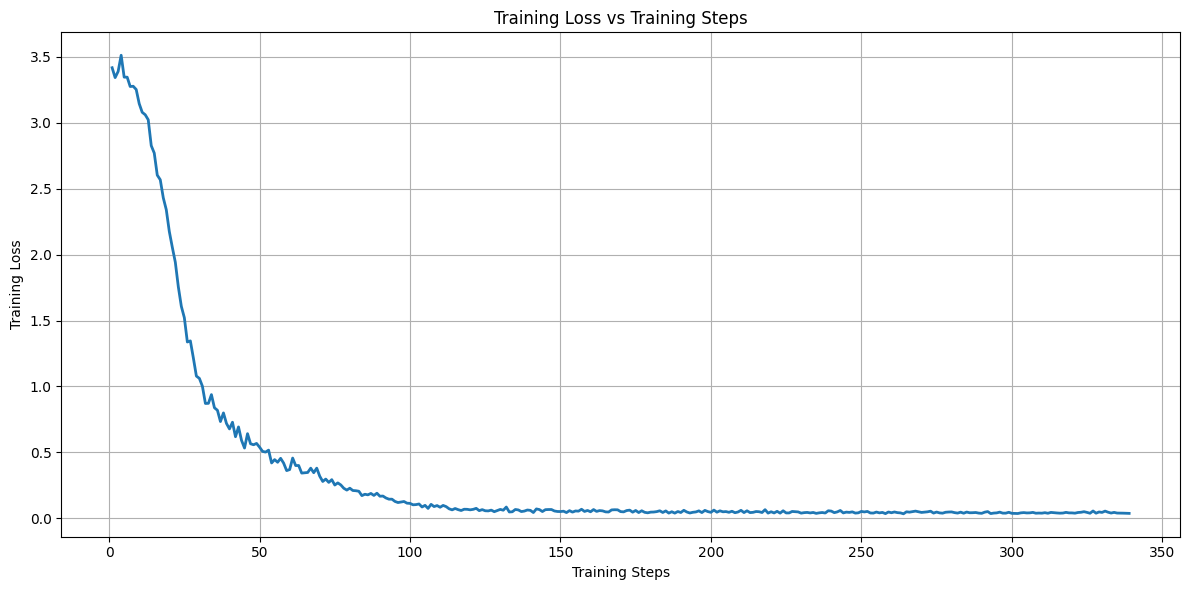

In [ ]:
import json
import matplotlib.pyplot as plt

# ----- Load metrics.json -----
# Nếu bạn đã load JSON vào biến (như bạn gửi) thì bỏ đoạn open() này
with open("/content/drive/MyDrive/Quang Huy/MedicalChatbotFinetune/MetricResult/metrics_2.json", "r") as f:
    data = json.load(f)

training_steps = data["training_steps"]
training_loss = data["training_loss"]

# ----- Plot -----
plt.figure(figsize=(12, 6))
plt.plot(training_steps, training_loss, linewidth=2)
plt.title("Training Loss vs Training Steps")
plt.xlabel("Training Steps")
plt.ylabel("Training Loss")
plt.grid(True)
plt.tight_layout()

plt.show()


### eval loss

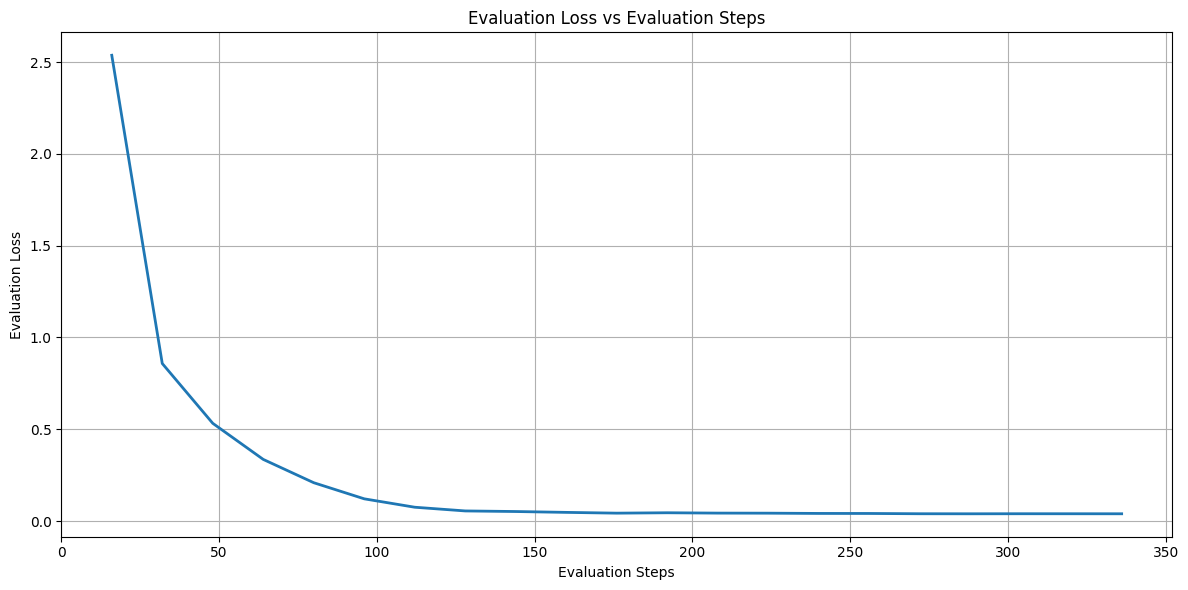

In [ ]:
evaluation_steps = data["evaluation_steps"]
evaluation_loss = data["eval_loss"]

plt.figure(figsize=(12, 6))
plt.plot(evaluation_steps, evaluation_loss, linewidth=2)
plt.title("Evaluation Loss vs Evaluation Steps")
plt.xlabel("Evaluation Steps")
plt.ylabel("Evaluation Loss")
plt.grid(True)
plt.tight_layout()

plt.show()


### both

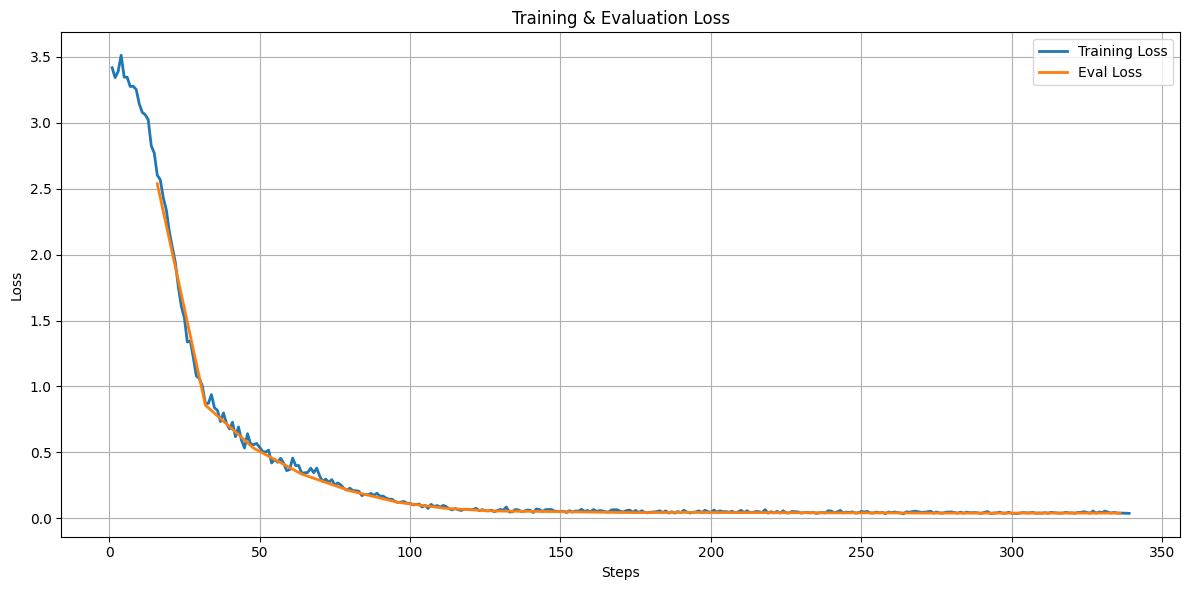

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(training_steps, training_loss, label="Training Loss", linewidth=2)
plt.plot(evaluation_steps, evaluation_loss, label="Eval Loss", linewidth=2)
plt.title("Training & Evaluation Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## so sánh TTFT, ITPS, OET, ...

In [ ]:
import json
import random
import time
import torch
import psutil
from unsloth import FastLanguageModel
from transformers import TextStreamer
import numpy as np

# ============================
# 1. Load dataset + lấy 10 mẫu
# ============================

json_path = "/content/drive/MyDrive/Quang Huy/MedicalChatbotFinetune/Dataset/pediatric_samples_v2.json"

with open(json_path, "r", encoding="utf-8") as f:
    dataset = json.load(f)

# Random 10 samples
samples = random.sample(dataset, 10)
print("Selected 10 samples.")


Selected 10 samples.


In [ ]:
print(samples[0])

{'instruction': 'Bạn là bác sĩ nhi khoa, có nhiệm vụ đưa ra gợi ý chăm sóc ban đầu rất ngắn gọn cho trẻ em dựa trên các triệu chứng được cung cấp. Không nêu chẩn đoán sâu, không hướng dẫn điều trị chi tiết. Chỉ đưa ra lời khuyên cơ bản, an toàn.', 'question': 'Bệnh: Ngứa da nhẹ. Triệu chứng: da khô, ngứa râm ran, lấm tấm đỏ.', 'answer': '- Mặc đồ mềm.\n- Giữ da sạch.\n- Theo dõi nếu lan rộng.'}


In [ ]:

# Convert dataset to prompt format
def build_prompt(sample):
    return f"{sample['instruction']}\n\nCâu hỏi: {sample['question']}\n\nTrả lời:"


# ============================
# Streamer tính token/time
# ============================
class TimingStreamer(TextStreamer):
    def __init__(self, tokenizer):
        super().__init__(tokenizer)
        self.token_count = 0
        self.first_token_time = None

    def on_finalized_text(self, text, stream_end=False):
        if self.token_count == 0:
            self.first_token_time = time.time()
        self.token_count += 1

# ============================
# 3. Benchmark từng sample
# ============================
results = []

process = psutil.Process()

for i, sample in enumerate(samples):
    print(f"\nRunning sample {i+1}/10 ...")

    prompt = build_prompt(sample)

    # encode
    encoded = tokenizer(prompt, return_tensors="pt")
    input_ids = encoded.input_ids.cuda()

    # input token count
    input_token_len = input_ids.shape[1]

    # RAM before
    ram_before = process.memory_info().rss / (1024**3)

    # Streamer
    streamer = TimingStreamer(tokenizer)

    # Timing
    start_time = time.time()

    output = model.generate(
        input_ids,
        max_new_tokens=150,
        temperature=0.7,
        streamer=streamer
    )

    end_time = time.time()

    # Extract
    TTFT = streamer.first_token_time - start_time
    OET = end_time - start_time
    OTPS = streamer.token_count / OET
    ITPS = streamer.token_count / (end_time - streamer.first_token_time)

    # RAM & CPU
    ram_after = process.memory_info().rss / (1024**3)
    ram_used = ram_after - ram_before
    cpu_usage = process.cpu_percent(interval=0.2)

    results.append({
        "input_tokens": input_token_len,
        "TTFT": TTFT,
        "ITPS": ITPS,
        "OET": OET,
        "OTPS": OTPS,
        "Total Time": OET,
        "CPU%": cpu_usage,
        "RAM_GB": ram_used
    })


# ============================
# 4. Tính mean giống bài báo
# ============================

mean_tokens = np.mean([r["input_tokens"] for r in results])
mean_TTFT = np.mean([r["TTFT"] for r in results])
mean_ITPS = np.mean([r["ITPS"] for r in results])
mean_OET = np.mean([r["OET"] for r in results])
mean_OTPS = np.mean([r["OTPS"] for r in results])
mean_CPU = np.mean([r["CPU%"] for r in results])
mean_RAM = np.mean([r["RAM_GB"] for r in results])

print("\n================ FINAL BENCHMARK RESULTS ================")
print(f"Model: {model_name}")
print(f"Mean Input Tokens: {mean_tokens:.2f}")
print(f"TTFT(s): {mean_TTFT:.4f}")
print(f"ITPS(t/s): {mean_ITPS:.2f}")
print(f"OET(s): {mean_OET:.4f}")
print(f"OTPS(t/s): {mean_OTPS:.2f}")
print(f"CPU(%): {mean_CPU:.2f}")
print(f"RAM(GB): {mean_RAM:.3f}")
print("========================================================\n")


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



Running sample 1/10 ...

Running sample 2/10 ...

Running sample 3/10 ...

Running sample 4/10 ...

Running sample 5/10 ...

Running sample 6/10 ...

Running sample 7/10 ...

Running sample 8/10 ...

Running sample 9/10 ...

Running sample 10/10 ...

================ FINAL BENCHMARK RESULTS ================
Model: unsloth/Llama-3.2-1B-Instruct
Mean Input Tokens: 97.10
TTFT(s): 0.0114
ITPS(t/s): 25.75
OET(s): 2.4627
OTPS(t/s): 25.52
CPU(%): 0.00
RAM(GB): 0.000



## Lưu model

In [ ]:
save_path = "/content/drive/MyDrive/Quang Huy/MedicalChatbotFinetune/OutputModel"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print("Đã lưu model và tokenizer vào:", save_path)

Đã lưu model và tokenizer vào: /content/drive/MyDrive/Quang Huy/MedicalChatbotFinetune/OutputModel
